In [1]:
from mlx.nn import ReLU
import mlx.data as dx
import mlx.core as mx

from src.config import OptimizerConfig, EncoderConfig
from src.processing import get_all_dataset, get_trades_tokenizer, get_volatility_seq, save_tokenizer, load_tokenizer, get_num_embedding, compute_df_feature, encode_df_feature

CATEGORIAL_COLUMNS = ["TradeType", "MifidInstrumentID", "MmtMarketMechanism", "MmtTradingMode", "MmtAlgorithmicIndicator", "Venue"]
CONTINUOUS_COLUMNS = ["delta_event_ts", "log_return", "log_volume", "norm_log_return", "norm_volume"]
SEQUENCE_SIZE = 60
VOLATILITY_SCALE = 10
SAVE_DIR = "weight"

dataset = get_all_dataset(dir="equities_trade")

print(f"👾 Load {len(dataset)} trades")
print(dataset.tail(1))

tokenizer = get_trades_tokenizer(dataset, cat_columns= CATEGORIAL_COLUMNS)
save_tokenizer(tokenizer=tokenizer, path="tokenizer.json")
del(tokenizer)
tokenizer = load_tokenizer(path="tokenizer.json") # test save & load

dataset = encode_df_feature(dataset, tokenizer)
dataset = compute_df_feature(dataset, norm_log_return_window=10, norm_volume_window=10)


encoder_config = EncoderConfig(num_continuous_col=len(CONTINUOUS_COLUMNS), 
                              depth=4,
                              embedding_dim=[4, 8, 4, 4, 4, 4],
                              num_embedding=get_num_embedding(dataset, CATEGORIAL_COLUMNS),
                              categorical_col=CATEGORIAL_COLUMNS)


Found 6 files in directory
👾 Load 6427974 trades
shape: (1, 12)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────┐
│ EventTime  ┆ TradingDat ┆ Publicatio ┆ MifidInst ┆ … ┆ MmtMarket ┆ MmtTradin ┆ MmtAlgori ┆ Venue │
│ ---        ┆ eTime      ┆ nDateTime  ┆ rumentID  ┆   ┆ Mechanism ┆ gMode     ┆ thmicIndi ┆ ---   │
│ str        ┆ ---        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ cator     ┆ str   │
│            ┆ str        ┆ str        ┆ str       ┆   ┆ str       ┆ str       ┆ ---       ┆       │
│            ┆            ┆            ┆           ┆   ┆           ┆           ┆ str       ┆       │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════╡
│ 2026-03-12 ┆ 2026-03-12 ┆ 2026-03-12 ┆ FR001400A ┆ … ┆ 4         ┆ 5         ┆ human     ┆ XPAR  │
│ T16:55:52. ┆ T16:55:23. ┆ T16:55:53. ┆ HX6       ┆   ┆           ┆           ┆           ┆       │
│ 000000000Z ┆ 000000Z    ┆

====== Volatility Model =====

Found 6 files in directory
👾 Load 6427974 trades
shape: (1, 12)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────┐
│ EventTime  ┆ TradingDat ┆ Publicatio ┆ MifidInst ┆ … ┆ MmtMarket ┆ MmtTradin ┆ MmtAlgori ┆ Venue │
│ ---        ┆ eTime      ┆ nDateTime  ┆ rumentID  ┆   ┆ Mechanism ┆ gMode     ┆ thmicIndi ┆ ---   │
│ str        ┆ ---        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ cator     ┆ str   │
│            ┆ str        ┆ str        ┆ str       ┆   ┆ str       ┆ str       ┆ ---       ┆       │
│            ┆            ┆            ┆           ┆   ┆           ┆           ┆ str       ┆       │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════╡
│ 2026-03-12 ┆ 2026-03-12 ┆ 2026-03-12 ┆ FR001400A ┆ … ┆ 4         ┆ 5         ┆ human     ┆ XPAR  │
│ T16:55:52. ┆ T16:55:23. ┆ T16:55:53. ┆ HX6       ┆   ┆           ┆           ┆           ┆       │
│ 000000000Z ┆ 000000Z    ┆

100%|██████████| 598/598 [00:56<00:00, 10.53it/s]


Target mean -->  0.00071875384 +/- 0.0035711008
MLX Buffer size --> 6362775
EPOCH 1 --- 


8700it [36:19,  3.99it/s]


TRAIN LOSS 0.002971801681454757 ||| TEST LOSS 0.002442270086428356
EPOCH 2 --- 


...

TRAIN LOSS 0.0029642573993267653 ||| TEST LOSS 0.0024404404501583766
EPOCH 9 --- 


8700it [40:39,  3.57it/s]


TRAIN LOSS 0.002966749700862141 ||| TEST LOSS 0.0024407237094094423
EPOCH 10 --- 


8700it [38:38,  3.75it/s]


TRAIN LOSS 0.00296941258802196 ||| TEST LOSS 0.0024402859025342886


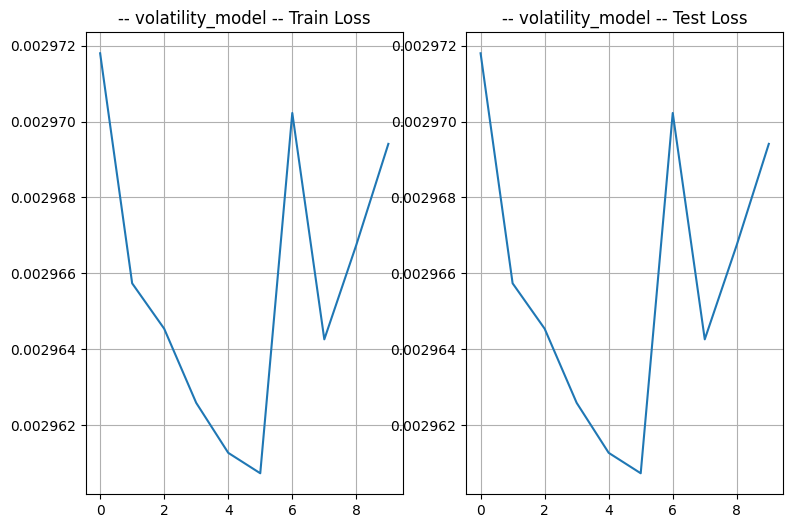

In [ ]:
from src.trainer import VolatilityTrainer
from src.volatility_nn import VolatilityPredictor
from src.config import VolatilityConfig


volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)

optimizer_config = OptimizerConfig(optimizer_name="adam", lr=1e-4)
volatility_model = VolatilityPredictor(encoder_config=encoder_config, volatility_config=volatility_config)
mx.eval(volatility_model.parameters())


sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)
print(f"MLX Buffer size --> {len(buffer)}")

trainer = VolatilityTrainer(model=volatility_model, 
                            optim_config=optimizer_config, 
                            buffer=buffer, 
                            categorical_columns=CATEGORIAL_COLUMNS, 
                            train_size=0.7,
                            batch_size=1024,
                            scale= VOLATILITY_SCALE)

trainer.epoch(n_epoch=10, 
              save_dir=SAVE_DIR, 
              model_name="volatility_model", 
              plot_chart=True)



In [ ]:
from src.analysis import analyse_volatility_residuals
from src.volatility_nn import VolatilityPredictor
from src.config import VolatilityConfig

TRAIN_SIZE=0.7

volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)

volatility_model = VolatilityPredictor(encoder_config=encoder_config, volatility_config=volatility_config)
volatility_model.load_weights("weight/volatility_model.safetensors")
mx.eval(volatility_model.parameters())

sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)

train_lenght = int(len(buffer)*TRAIN_SIZE)
buffer_train = dx.buffer_from_vector([buffer[i] for i in range(train_lenght)])
buffer_test = dx.buffer_from_vector([buffer[i] for i in range(train_lenght, len(buffer))])

volatility_sequence_train = mx.array([buffer_train[i]["target"] for i in range(len(buffer_train))], dtype=mx.float32)
volatility_sequence_test = mx.array([buffer_test[i]["target"] for i in range(len(buffer_test))], dtype=mx.float32)

analyse_volatility_residuals(model=volatility_model, buffer=buffer_train, volatility_sequence=volatility_sequence_train, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="volatility_train")
analyse_volatility_residuals(model=volatility_model, buffer=buffer_test, volatility_sequence=volatility_sequence_test, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="volatility_test")


===========VAE MODEL===========

In [ ]:
#import importlib
#import src.vae
#importlib.reload(src.vae)
import time
from src.config import VAEConfig
from src.vae import VAE
from src.trainer import VAETrainer
from src.processing import get_vae_seq

vae_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

optim_vae_config = OptimizerConfig(
    optimizer_name="adamw", 
    lr = 1e-4
)

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
mx.eval(vae_model.parameters())

vae_sequence = get_vae_seq(data=dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
start = time.time()
vae_buffer = dx.buffer_from_vector(vae_sequence)
print('MLX buffer init in ', time.time() - start, "second")
vae_trainer = VAETrainer(model=vae_model, 
                         optim_config=optim_vae_config, 
                         buffer=vae_buffer, 
                         categorical_columns=CATEGORIAL_COLUMNS,
                         train_size=0.7, 
                         batch_size=1024) 

vae_trainer.epoch(n_epoch=10,
                  save_dir= SAVE_DIR,
                  model_name="vae",
                  plot_chart=True)


100%|██████████| 598/598 [00:17<00:00, 34.91it/s]


MLX buffer init in  27.671177864074707 second
MLX train buffer init in  15.911517858505249
MLX test buffer init in  8.679965734481812
EPOCH 1 --- 


4350it [57:30,  1.26it/s]
1865it [03:31,  8.81it/s]


TRAIN LOSS -178.1211420199515 ||| TEST LOSS -144.0472063079916
EPOCH 2 --- 


4350it [59:00,  1.23it/s]
1865it [03:52,  8.02it/s]


TRAIN LOSS -180.6069038303419 ||| TEST LOSS -144.04593248546283
EPOCH 3 --- 


2003it [27:54,  1.08it/s]

In [ ]:
from src.analysis import analyse_vae_residuals
from src.config import VAEConfig
from src.vae import VAE

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
vae_model = vae_model.load_weights("weight/vae.sefetensors")
mx.eval(vae_model.parameters())
TRAIN_SIZE=0.7

sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)
train_lenght = int(len(buffer)*TRAIN_SIZE)
buffer_train = dx.buffer_from_vector([buffer[i] for i in range(train_lenght)])
buffer_test = dx.buffer_from_vector([buffer[i] for i in range(train_lenght, len(buffer))])

volatility_sequence_train = mx.array([buffer_train[i]["target"] for i in range(len(buffer_train))], dtype=mx.float32)
volatility_sequence_test = mx.array([buffer_test[i]["target"] for i in range(len(buffer_test))], dtype=mx.float32)

analyse_vae_residuals(model=vae_model, buffer=buffer_train, volatility_sequence=volatility_sequence_train, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="vae_train")
analyse_vae_residuals(model=vae_model, buffer=buffer_test, volatility_sequence=volatility_sequence_test, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="vae_test")


In [ ]:
from src.config import DirectionalConfig
from src.directional_nn import DirectionalHead
from src.trainer import DiscretizedVolPredictor

